# 02 · Ingeniería de variables

## Predicción del riesgo de rotura de stock en un entorno logístico

En este notebook preparo las variables que utilizaré posteriormente para entrenar los modelos.

Parto del dataset original de ventas y creo variables basadas en:

- la fecha;
- las ventas de días anteriores;
- las medias móviles;
- la tendencia reciente;
- el precio;
- las promociones;
- un plazo de reposición simulado.

El dataset no contiene stock real ni roturas de stock observadas. Por este motivo, el target que voy a crear es una aproximación académica y debe interpretarse como un **riesgo sintético**, no como una rotura real.


## 1. Importación de librerías

Importo las librerías que necesito para trabajar con los datos, realizar cálculos y guardar el resultado.


In [8]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

RANDOM_STATE = 42


## 2. Definición de rutas

Utilizo la misma estructura de carpetas que en el notebook anterior.

El dataset procesado se guardará en `data/processed` y los resultados de este notebook se guardarán dentro de `outputs`.


In [9]:
# Compruebo desde qué carpeta se está ejecutando el notebook.
current_path = Path.cwd()

if current_path.name == "notebooks":
    project_path = current_path.parent
else:
    project_path = current_path

raw_data_path = project_path / "data" / "raw" / "retail_sales.csv"
processed_data_path = project_path / "data" / "processed" / "stockout_dataset.csv"

figures_path = project_path / "outputs" / "figures" / "feature_engineering"
tables_path = project_path / "outputs" / "tables" / "feature_engineering"

processed_data_path.parent.mkdir(parents=True, exist_ok=True)
figures_path.mkdir(parents=True, exist_ok=True)
tables_path.mkdir(parents=True, exist_ok=True)

print("Dataset original:", raw_data_path)
print("Dataset procesado:", processed_data_path)


Dataset original: c:\Users\lloro\Documents\GitHub\TFE_PROYECTO1\data\raw\retail_sales.csv
Dataset procesado: c:\Users\lloro\Documents\GitHub\TFE_PROYECTO1\data\processed\stockout_dataset.csv


## 3. Carga y revisión inicial

Cargo el dataset original y compruebo que contiene las columnas necesarias.

Después convierto la fecha y las variables numéricas al tipo adecuado. También ordeno los registros por tienda, producto y fecha, ya que los lags y las medias móviles dependen del orden temporal.


In [10]:
required_columns = [
    "date",
    "store_id",
    "item_id",
    "sales",
    "price",
    "promo"
]

if not raw_data_path.exists():
    raise FileNotFoundError(
        f"No se encuentra el archivo: {raw_data_path}"
    )

# Vuelvo a cargar el dataset original.
df = pd.read_csv(raw_data_path)

missing_columns = [
    column
    for column in required_columns
    if column not in df.columns
]

if missing_columns:
    raise ValueError(
        f"Faltan columnas obligatorias: {missing_columns}"
    )

# Convierto la fecha al formato adecuado.
df["date"] = pd.to_datetime(
    df["date"],
    errors="coerce"
)

# Solo convierto las variables que realmente son numéricas.
numeric_columns = [
    "sales",
    "price",
    "promo"
]

for column in numeric_columns:
    df[column] = pd.to_numeric(
        df[column],
        errors="coerce"
    )

# Mantengo tienda y producto como identificadores de texto.
df["store_id"] = df["store_id"].astype(str)
df["item_id"] = df["item_id"].astype(str)

# Elimino únicamente las filas que no tienen los datos básicos necesarios.
df = df.dropna(
    subset=required_columns
).copy()

# Ordeno los datos antes de crear lags y medias móviles.
df = df.sort_values(
    ["store_id", "item_id", "date"]
).reset_index(drop=True)

print("Shape inicial:", df.shape)
display(df.head())


Shape inicial: (4565000, 8)


,date,store_id,item_id,sales,price,promo,weekday,month
0,2019-01-01,store_1,item_1,41,21.30,0,1,1
1,2019-01-02,store_1,item_1,53,21.30,0,2,1
2,2019-01-03,store_1,item_1,39,21.30,0,3,1
3,2019-01-04,store_1,item_1,35,21.30,0,4,1
4,2019-01-05,store_1,item_1,51,17.04,1,5,1


## 4. Comprobación de duplicados

Espero encontrar una sola fila por fecha, tienda y producto.

Si existen duplicados para esa combinación, no continúo porque los lags y las medias móviles podrían calcularse de forma incorrecta.


In [11]:
key_columns = [
    "date",
    "store_id",
    "item_id"
]

duplicated_rows = df.duplicated(
    subset=key_columns
).sum()

print(
    "Duplicados por fecha, tienda y producto:",
    duplicated_rows
)

if duplicated_rows > 0:
    raise ValueError(
        "Existen duplicados por fecha, tienda y producto. "
        "Debo revisarlos antes de continuar."
    )


Duplicados por fecha, tienda y producto: 0


## 5. Variables temporales

Creo variables a partir de la fecha.

Estas variables permiten que el modelo aprenda posibles diferencias entre meses, días de la semana o fines de semana.


In [12]:
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["weekday"] = df["date"].dt.dayofweek
df["week"] = df["date"].dt.isocalendar().week.astype(int)

# Creo una variable que indica si el día es sábado o domingo.
df["is_weekend"] = (
    df["weekday"] >= 5
).astype(int)

display(
    df[[
        "date",
        "year",
        "month",
        "week",
        "weekday",
        "is_weekend"
    ]].head()
)


,date,year,month,week,weekday,is_weekend
0,2019-01-01,2019,1,1,1,0
1,2019-01-02,2019,1,1,2,0
2,2019-01-03,2019,1,1,3,0
3,2019-01-04,2019,1,1,4,0
4,2019-01-05,2019,1,1,5,1


## 6. Variables históricas de ventas

Creo lags para conocer las ventas anteriores de la misma tienda y producto.

Por ejemplo, `sales_lag_7` representa las ventas observadas siete registros antes dentro de la misma serie.

También creo medias móviles usando únicamente ventas anteriores. Para evitar utilizar la venta del mismo día dentro de la media, aplico primero un desplazamiento de un periodo.


In [13]:
group_columns = [
    "store_id",
    "item_id"
]

sales_group = df.groupby(
    group_columns
)["sales"]

# Creo variables con las ventas de días anteriores.
df["sales_lag_1"] = sales_group.shift(1)
df["sales_lag_7"] = sales_group.shift(7)
df["sales_lag_14"] = sales_group.shift(14)
df["sales_lag_30"] = sales_group.shift(30)


In [14]:
# Desplazo las ventas un día para que las medias móviles
# solo utilicen información conocida antes de la fecha actual.
shifted_sales = sales_group.shift(1)

df["rolling_mean_7"] = (
    shifted_sales
    .groupby([
        df["store_id"],
        df["item_id"]
    ])
    .transform(
        lambda series: series.rolling(
            window=7,
            min_periods=7
        ).mean()
    )
)

df["rolling_mean_14"] = (
    shifted_sales
    .groupby([
        df["store_id"],
        df["item_id"]
    ])
    .transform(
        lambda series: series.rolling(
            window=14,
            min_periods=14
        ).mean()
    )
)

df["rolling_mean_30"] = (
    shifted_sales
    .groupby([
        df["store_id"],
        df["item_id"]
    ])
    .transform(
        lambda series: series.rolling(
            window=30,
            min_periods=30
        ).mean()
    )
)

df["rolling_std_30"] = (
    shifted_sales
    .groupby([
        df["store_id"],
        df["item_id"]
    ])
    .transform(
        lambda series: series.rolling(
            window=30,
            min_periods=30
        ).std()
    )
)

display(
    df[[
        "store_id",
        "item_id",
        "date",
        "sales",
        "sales_lag_7",
        "rolling_mean_7",
        "rolling_mean_30",
        "rolling_std_30"
    ]].head(35)
)


,store_id,item_id,date,sales,sales_lag_7,rolling_mean_7,rolling_mean_30,rolling_std_30
0,store_1,item_1,2019-01-01,41,NaN,NaN,NaN,NaN
1,store_1,item_1,2019-01-02,53,NaN,NaN,NaN,NaN
2,store_1,item_1,2019-01-03,39,NaN,NaN,NaN,NaN
3,store_1,item_1,2019-01-04,35,NaN,NaN,NaN,NaN
4,store_1,item_1,2019-01-05,51,NaN,NaN,NaN,NaN
5,store_1,item_1,2019-01-06,38,NaN,NaN,NaN,NaN
6,store_1,item_1,2019-01-07,45,NaN,NaN,NaN,NaN
7,store_1,item_1,2019-01-08,48,41.00,43.14,NaN,NaN
8,store_1,item_1,2019-01-09,50,53.00,44.14,NaN,NaN
9,store_1,item_1,2019-01-10,44,39.00,43.71,NaN,NaN


## 7. Tendencia reciente

Creo una variable sencilla para comparar la demanda reciente con la demanda de un periodo más largo.

Si `trend_7_30` es positiva, la media de los últimos siete días es superior a la media de los últimos treinta días. Esto puede indicar un aumento reciente de la demanda.


In [15]:
df["trend_7_30"] = (
    df["rolling_mean_7"]
    - df["rolling_mean_30"]
)

display(
    df[[
        "rolling_mean_7",
        "rolling_mean_30",
        "trend_7_30"
    ]].describe().T
)


,count,mean,std,min,25%,50%,75%,max
rolling_mean_7,"4,547,500.00",29.26,13.36,3.00,18.43,27.57,38.14,97.14
rolling_mean_30,"4,490,000.00",29.26,13.23,5.20,18.40,27.60,38.10,85.77
trend_7_30,"4,490,000.00",0.02,2.26,-14.92,-1.39,-0.04,1.34,18.73


## 8. Variables de precio y promoción

Mantengo el precio y la promoción actuales porque son datos conocidos en la fecha de predicción.

También creo dos variables sencillas:

- el precio medio de los últimos 30 días;
- el número de días con promoción durante los últimos 7 días.

Estas variables pueden ayudar a explicar cambios de demanda.


In [16]:
price_group = df.groupby(
    group_columns
)["price"]

shifted_price = price_group.shift(1)

df["rolling_price_mean_30"] = (
    shifted_price
    .groupby([
        df["store_id"],
        df["item_id"]
    ])
    .transform(
        lambda series: series.rolling(
            window=30,
            min_periods=30
        ).mean()
    )
)

promo_group = df.groupby(
    group_columns
)["promo"]

shifted_promo = promo_group.shift(1)

df["promo_days_last_7"] = (
    shifted_promo
    .groupby([
        df["store_id"],
        df["item_id"]
    ])
    .transform(
        lambda series: series.rolling(
            window=7,
            min_periods=7
        ).sum()
    )
)

display(
    df[[
        "price",
        "rolling_price_mean_30",
        "promo",
        "promo_days_last_7"
    ]].head(35)
)


,price,rolling_price_mean_30,promo,promo_days_last_7
0,21.30,NaN,0,NaN
1,21.30,NaN,0,NaN
2,21.30,NaN,0,NaN
3,21.30,NaN,0,NaN
4,17.04,NaN,1,NaN
5,21.30,NaN,0,NaN
6,21.30,NaN,0,NaN
7,21.30,NaN,0,1.00
8,21.30,NaN,0,1.00
9,21.30,NaN,0,1.00


## 9. Simulación del plazo de reposición

El dataset no contiene el plazo real de reposición.

Para poder construir el ejercicio, asigno un `lead_time_days` sencillo según el producto. El resultado siempre estará entre 1 y 7 días y será estable para el mismo producto.

Esta variable es simulada y debe sustituirse por un dato real si el proyecto se utilizara en una empresa.


In [18]:
# Extraigo la parte numérica del identificador del producto.
item_number = (
    df["item_id"]
    .str.extract(r"(\d+)")
    .astype(int)[0]
)

# Creo un plazo de reposición simulado entre 1 y 7 días.
df["lead_time_days"] = (
    item_number % 7
) + 1

display(
    df[
        [
            "item_id",
            "lead_time_days"
        ]
    ]
    .drop_duplicates()
    .head(15)
)

,item_id,lead_time_days
0,item_1,2
1826,item_10,4
3652,item_11,5
5478,item_12,6
7304,item_13,7
9130,item_14,1
10956,item_15,2
12782,item_16,3
14608,item_17,4
16434,item_18,5


## 10. Creación de la demanda futura

Para construir el target necesito conocer la demanda de los próximos siete días.

Estas variables futuras se utilizan únicamente para crear la etiqueta. No se utilizarán como variables de entrada de los modelos, porque eso produciría fuga de información.


In [19]:
future_sales_columns = []

for day_ahead in range(1, 8):
    column_name = f"future_sales_d{day_ahead}"

    df[column_name] = sales_group.shift(
        -day_ahead
    )

    future_sales_columns.append(
        column_name
    )

# Sumo las ventas de los siete días siguientes.
# min_count=7 obliga a tener los siete días disponibles.
df["future_demand_7d"] = df[
    future_sales_columns
].sum(
    axis=1,
    min_count=7
)

display(
    df[[
        "date",
        "sales",
        *future_sales_columns,
        "future_demand_7d"
    ]].head(10)
)


,date,sales,future_sales_d1,future_sales_d2,future_sales_d3,future_sales_d4,future_sales_d5,future_sales_d6,future_sales_d7,future_demand_7d
0,2019-01-01,41,53.00,39.00,35.00,51.00,38.00,45.00,48.00,309.00
1,2019-01-02,53,39.00,35.00,51.00,38.00,45.00,48.00,50.00,306.00
2,2019-01-03,39,35.00,51.00,38.00,45.00,48.00,50.00,44.00,311.00
3,2019-01-04,35,51.00,38.00,45.00,48.00,50.00,44.00,38.00,314.00
4,2019-01-05,51,38.00,45.00,48.00,50.00,44.00,38.00,30.00,293.00
5,2019-01-06,38,45.00,48.00,50.00,44.00,38.00,30.00,48.00,303.00
6,2019-01-07,45,48.00,50.00,44.00,38.00,30.00,48.00,40.00,298.00
7,2019-01-08,48,50.00,44.00,38.00,30.00,48.00,40.00,46.00,296.00
8,2019-01-09,50,44.00,38.00,30.00,48.00,40.00,46.00,47.00,293.00
9,2019-01-10,44,38.00,30.00,48.00,40.00,46.00,47.00,46.00,295.00


## 11. Creación del target sintético

Como no dispongo de inventario real, creo una estimación sencilla del stock disponible.

Utilizo la media de ventas de los últimos 30 días multiplicada por el plazo de reposición. Después añado un pequeño margen de seguridad basado en la variabilidad de las ventas.

Considero que existe riesgo cuando la demanda futura de siete días supera el stock estimado más el stock de seguridad.


In [20]:
# Estimo un stock equivalente a la demanda media
# durante el plazo de reposición.
df["stock_estimated"] = (
    df["rolling_mean_30"]
    * df["lead_time_days"]
)

# Creo un margen de seguridad sencillo.
df["safety_stock"] = (
    df["rolling_std_30"]
    * np.sqrt(df["lead_time_days"])
)

df["stockout_risk"] = np.where(
    (
        df["future_demand_7d"].notna()
        & df["stock_estimated"].notna()
        & df["safety_stock"].notna()
    ),
    (
        df["future_demand_7d"]
        > (
            df["stock_estimated"]
            + df["safety_stock"]
        )
    ).astype(int),
    np.nan
)

display(
    df[[
        "future_demand_7d",
        "stock_estimated",
        "safety_stock",
        "stockout_risk"
    ]].head(40)
)


,future_demand_7d,stock_estimated,safety_stock,stockout_risk
0,309.00,NaN,NaN,NaN
1,306.00,NaN,NaN,NaN
2,311.00,NaN,NaN,NaN
3,314.00,NaN,NaN,NaN
4,293.00,NaN,NaN,NaN
5,303.00,NaN,NaN,NaN
6,298.00,NaN,NaN,NaN
7,296.00,NaN,NaN,NaN
8,293.00,NaN,NaN,NaN
9,295.00,NaN,NaN,NaN


## 12. Selección de variables para el modelado

Selecciono un conjunto reducido de variables que puedo explicar con claridad.

No incluyo las ventas futuras, el stock estimado ni el stock de seguridad porque participan directamente en la creación del target.


In [21]:
model_features = [
    "sales",
    "price",
    "promo",
    "year",
    "month",
    "week",
    "weekday",
    "is_weekend",
    "sales_lag_1",
    "sales_lag_7",
    "sales_lag_14",
    "sales_lag_30",
    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_mean_30",
    "rolling_std_30",
    "trend_7_30",
    "rolling_price_mean_30",
    "promo_days_last_7",
    "lead_time_days"
]

print(
    f"Número de variables seleccionadas: "
    f"{len(model_features)}"
)

print(model_features)


Número de variables seleccionadas: 20
['sales', 'price', 'promo', 'year', 'month', 'week', 'weekday', 'is_weekend', 'sales_lag_1', 'sales_lag_7', 'sales_lag_14', 'sales_lag_30', 'rolling_mean_7', 'rolling_mean_14', 'rolling_mean_30', 'rolling_std_30', 'trend_7_30', 'rolling_price_mean_30', 'promo_days_last_7', 'lead_time_days']


## 13. Tratamiento de valores nulos

Los primeros registros de cada serie no tienen suficiente historial para calcular los lags y las medias móviles.

Los últimos siete registros tampoco tienen la demanda futura completa.

Elimino únicamente las filas que no tienen alguna variable necesaria para el modelado o para el target.


In [22]:
required_for_model = (
    model_features
    + ["stockout_risk"]
)

print("Shape antes del filtrado:", df.shape)

valid_rows = df[
    required_for_model
].notna().all(axis=1)

df_model = df.loc[
    valid_rows
].copy()

df_model["stockout_risk"] = (
    df_model["stockout_risk"]
    .astype(int)
)

df_model = df_model.sort_values(
    ["date", "store_id", "item_id"]
).reset_index(drop=True)

print("Shape después del filtrado:", df_model.shape)
print(
    "Filas eliminadas:",
    len(df) - len(df_model)
)


Shape antes del filtrado: (4565000, 34)
Shape después del filtrado: (4472500, 34)
Filas eliminadas: 92500


## 14. Distribución del target

Reviso cuántos registros tienen riesgo y qué proporción representan.

Esta comprobación es importante porque un target muy desbalanceado puede afectar a la elección de las métricas durante el entrenamiento.


,stockout_risk,count,proportion
0,0,685980,0.15
1,1,3786520,0.85


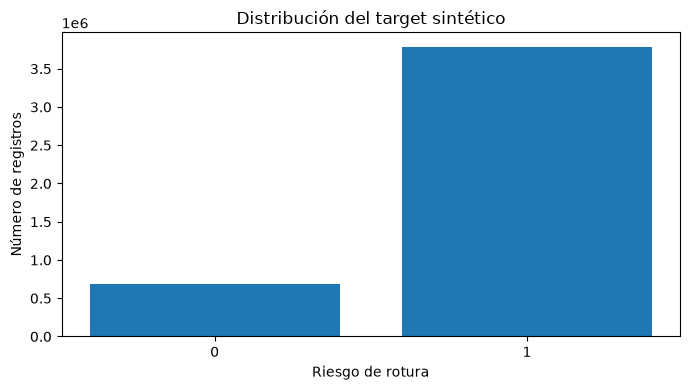

In [23]:
target_distribution = (
    df_model["stockout_risk"]
    .value_counts()
    .sort_index()
    .rename_axis("stockout_risk")
    .reset_index(name="count")
)

target_distribution["proportion"] = (
    target_distribution["count"]
    / len(df_model)
)

display(target_distribution)

target_distribution.to_csv(
    tables_path / "target_distribution.csv",
    index=False
)

plt.figure(figsize=(7, 4))

plt.bar(
    target_distribution[
        "stockout_risk"
    ].astype(str),
    target_distribution["count"]
)

plt.title("Distribución del target sintético")
plt.xlabel("Riesgo de rotura")
plt.ylabel("Número de registros")
plt.tight_layout()

plt.savefig(
    figures_path / "target_distribution.png",
    dpi=150
)

plt.show()


## 15. Comprobación de fuga de información

Compruebo que las variables utilizadas para construir el target no aparezcan dentro de `model_features`.

Esta comprobación evita que el modelo aprenda directamente la fórmula utilizada para crear la etiqueta.


In [24]:
forbidden_features = [
    *future_sales_columns,
    "future_demand_7d",
    "stock_estimated",
    "safety_stock",
    "stockout_risk"
]

leakage_features = [
    feature
    for feature in model_features
    if feature in forbidden_features
]

if leakage_features:
    raise ValueError(
        "Se han encontrado variables con fuga de información: "
        f"{leakage_features}"
    )

print("Control de fuga de información superado.")


Control de fuga de información superado.


## 16. Guardado del dataset procesado

Guardo el dataset completo porque en los siguientes notebooks necesitaré:

- la fecha;
- la tienda;
- el producto;
- las variables del modelo;
- el target;
- algunas variables auxiliares para analizar los resultados.

En el notebook de entrenamiento seleccionaré únicamente las columnas incluidas en `model_features`.


In [25]:
df_model.to_csv(
    processed_data_path,
    index=False
)

feature_table = pd.DataFrame({
    "feature": model_features
})

feature_table.to_csv(
    tables_path / "model_features.csv",
    index=False
)

print(
    "Dataset procesado guardado en:",
    processed_data_path
)

print("Shape final:", df_model.shape)

display(
    df_model[
        [
            "date",
            "store_id",
            "item_id",
            *model_features,
            "stockout_risk"
        ]
    ].head()
)


Dataset procesado guardado en: c:\Users\lloro\Documents\GitHub\TFE_PROYECTO1\data\processed\stockout_dataset.csv
Shape final: (4472500, 34)


,date,store_id,item_id,sales,price,promo,year,month,week,weekday,is_weekend,sales_lag_1,sales_lag_7,sales_lag_14,sales_lag_30,rolling_mean_7,rolling_mean_14,rolling_mean_30,rolling_std_30,trend_7_30,rolling_price_mean_30,promo_days_last_7,lead_time_days,stockout_risk
0,2019-01-31,store_1,item_1,50,21.30,0,2019,1,5,3,0,57.00,40.00,46.00,41.00,42.71,42.14,42.77,6.25,-0.05,21.02,0.00,2,1
1,2019-01-31,store_1,item_10,36,16.47,1,2019,1,5,3,0,44.00,24.00,24.00,18.00,21.86,22.93,21.37,6.92,0.49,20.18,1.00,4,1
2,2019-01-31,store_1,item_11,26,65.25,0,2019,1,5,3,0,29.00,21.00,24.00,27.00,21.57,22.29,22.63,5.66,-1.06,64.81,0.00,5,1
3,2019-01-31,store_1,item_12,20,60.88,0,2019,1,5,3,0,26.00,23.00,19.00,13.00,22.57,21.43,19.50,5.48,3.07,58.85,2.00,6,1
4,2019-01-31,store_1,item_13,37,68.19,0,2019,1,5,3,0,47.00,43.00,39.00,41.00,38.29,37.00,37.10,7.92,1.19,67.28,0.00,7,0


## 17. Comprobaciones finales

Realizo unas comprobaciones sencillas antes de cerrar el notebook:

- no debe haber duplicados por fecha, tienda y producto;
- no debe haber nulos en las variables seleccionadas;
- el target solo puede contener 0 y 1;
- el archivo procesado debe haberse creado correctamente.


In [26]:
assert df_model[
    ["date", "store_id", "item_id"]
].duplicated().sum() == 0

assert df_model[
    required_for_model
].isna().sum().sum() == 0

assert set(
    df_model["stockout_risk"].unique()
).issubset({0, 1})

assert processed_data_path.exists()

print(
    "Todas las comprobaciones finales "
    "se han superado."
)


Todas las comprobaciones finales se han superado.


## 18. Conclusiones

En este notebook he creado un conjunto de variables sencillo y fácil de justificar:

- variables temporales;
- ventas anteriores;
- medias móviles;
- variabilidad de la demanda;
- tendencia reciente;
- precio y promoción;
- plazo de reposición simulado.

También he creado un target sintético para representar el riesgo de rotura de stock.


